## EDA — DataCo Supply Chain (cleaned)

This notebook is **EDA only**.

**Input expected:** a cleaned dataset exported from `notebooks/data_cleaned.ipynb` (e.g. `dataco_cleaned.csv`).

**Goal:** extract the strongest, most defensible insights (especially around `Late_delivery_risk`) and highlight any data quality issues or leakage risks that matter for modeling and business decisions.


In [5]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


### Step 1 – Load the cleaned dataset

Here we **read the already-cleaned CSV** (`dataco_cleaned.csv`) created by the cleaning notebook and store it in a DataFrame called `df`.

- We try a few common paths and print which one is used.
- We show the **shape** (rows, columns) and preview the **first 3 rows** so we can see the final column names and a couple of example records.

In [6]:
# ---- Data loading (expects cleaned CSV) ----
# Put the cleaned file in one of these locations (recommended first):
#   - ../data/dataco_cleaned.csv
#   - ./dataco_cleaned.csv
#   - ../notebooks/dataco_cleaned.csv

CANDIDATE_PATHS = [
    Path("..").joinpath("data", "dataco_cleaned.csv"),
    Path("dataco_cleaned.csv"),
    Path("..").joinpath("notebooks", "dataco_cleaned.csv"),
]


def load_cleaned_df(path: str | Path | None = None) -> pd.DataFrame:
    if path is not None:
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(f"File not found: {p.resolve()}")
        return pd.read_csv(p)

    for p in CANDIDATE_PATHS:
        if p.exists():
            print(f"Loading: {p}")
            return pd.read_csv(p)

    searched = "\n".join([f"- {p.resolve()}" for p in CANDIDATE_PATHS])
    raise FileNotFoundError(
        "Could not find `dataco_cleaned.csv`.\n\n"
        "Place it in one of these locations and re-run this cell:\n"
        f"{searched}\n\n"
        "Tip: run the cleaning notebook to export it, then copy it into ../data/"
    )


df = load_cleaned_df()
print(df.shape)
df.head(3)


Loading: ..\data\dataco_cleaned.csv
(180519, 47)


,transaction_type,shipping_days_actual,shipping_days_scheduled,profit_per_order,customer_total_sales,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,Customer Street,customer_zipcode,department_id,department_name,store_latitude,store_longitude,market,order_city,order_country,order_date,order_id,item_discount_amount,item_discount_rate,order_item_id,Order Item Product Price,item_profit_ratio,item_quantity,item_sales,item_total,order_region,order_state,order_status,product_id,product_name,product_price,product_availability,shipping_date,shipping_mode,profit_ratio_extreme_loss,order_year,order_month,order_weekday,order_quarter
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,2018-01-31 22:56:00,77202,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,Southeast Asia,Java Occidental,COMPLETE,1360,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,0,2018,1,2,1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,2018-01-13 12:27:00,75939,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,South Asia,Rajastán,PENDING,1360,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,0,2018,1,5,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,2018-01-13 12:06:00,75938,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,South Asia,Rajastán,CLOSED,1360,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0,2018,1,5,1


### Step 2 – Check structure, duplicates, and missing values

In this step we answer:
- *What columns and dtypes do we have?* → `df.info()`
- *Are there duplicated rows?* → `df.duplicated()`
- *Do we still have any missing values? In which columns and how much?* → we compute a small **missingness table** and (if needed) plot a bar chart of missing % per column.

This gives a **quick health check** that the cleaned dataset is consistent and complete.

In [7]:
# ---- Quick structural audit ----

display(df.info())

n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,} | Columns: {n_cols:,}")

# Duplicate rows (exact)
dup_n = int(df.duplicated().sum())
print(f"Exact duplicate rows: {dup_n:,} ({dup_n / max(n_rows, 1) * 100:.2f}%)")

# Missingness table
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
missing_tbl = missing_tbl[missing_tbl["missing"] > 0]

if len(missing_tbl) == 0:
    print("No missing values.")
else:
    display(missing_tbl)
    plt.figure(figsize=(12, max(4, 0.25 * len(missing_tbl))))
    sns.barplot(
        data=missing_tbl.reset_index().rename(columns={"index": "column"}),
        y="column",
        x="missing_%",
        color=sns.color_palette()[0],
    )
    plt.title("Missingness by column (%)")
    plt.xlabel("Missing %")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 47 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_type           180519 non-null  object 
 1   shipping_days_actual       180519 non-null  int64  
 2   shipping_days_scheduled    180519 non-null  int64  
 3   profit_per_order           180519 non-null  float64
 4   customer_total_sales       180519 non-null  float64
 5   delivery_status            180519 non-null  object 
 6   late_delivery_risk         180519 non-null  int64  
 7   category_id                180519 non-null  int64  
 8   category_name              180519 non-null  object 
 9   customer_city              180519 non-null  object 
 10  customer_country           180519 non-null  object 
 11  customer_id                180519 non-null  int64  
 12  customer_segment           180519 non-null  object 
 13  customer_state             18

None

Rows: 180,519 | Columns: 47
Exact duplicate rows: 0 (0.00%)
No missing values.


### Step 3 – Understand the target: `late_delivery_risk`

Goal: understand how imbalanced the **classification label** is.

- We check that the `late_delivery_risk` column exists.
- We count how many orders are **on time (0)** vs **late (1)**.
- We compute the **overall late rate** (percentage of orders that are late).
- We plot a simple **bar chart** to visualize class balance.
- We also compute a **majority-class baseline accuracy** (how good you’d be if you always predicted the most common class).

This tells us how hard the classification problem is and what baseline any model must beat.

late_delivery_risk
0    81542
1    98977
Name: count, dtype: int64
Late rate: 0.548 (54.8%)


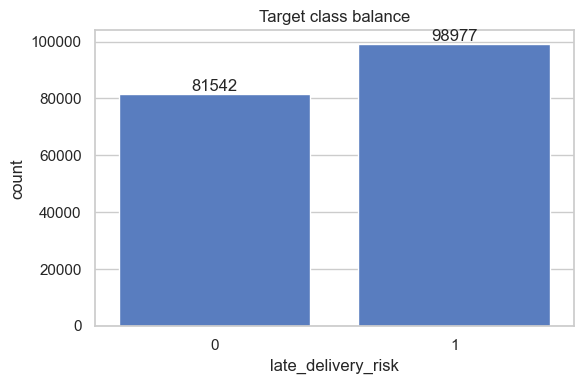

Majority-class baseline accuracy: 0.548 (predict 1 always)


In [8]:
# ---- Target overview (Late_delivery_risk) ----

TARGET = "late_delivery_risk"
if TARGET not in df.columns:
    raise KeyError(f"Expected target column not found: {TARGET}")

# Validate target values
vc = df[TARGET].value_counts(dropna=False).sort_index()
print(vc)

late_rate = df[TARGET].mean()
print(f"Late rate: {late_rate:.3f} ({late_rate*100:.1f}%)")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=TARGET, data=df)
ax.bar_label(ax.containers[0])
plt.title("Target class balance")
plt.tight_layout()
plt.show()

# Helpful baseline for any classifier
majority = int(vc.idxmax()) if len(vc) else None
baseline_acc = float(vc.max() / len(df)) if len(df) else math.nan
print(f"Majority-class baseline accuracy: {baseline_acc:.3f} (predict {majority} always)")


### Step 4 – Check for potential leakage columns

Some columns describe **outcomes that happen after the prediction point**, not inputs we would know in advance (for example, actual shipping time or final delivery status).

- We highlight columns such as `shipping_days_actual`, `delivery_status`, and `shipping_date`.
- We print which of these are present in the cleaned data.
- For the numeric ones, we show how strongly they separate late vs non-late shipments.

These are **red-flag features** that must **not** be used as predictors in a real model, but it’s useful to see how powerful they are to understand the mechanics of the process.

In [9]:
# ---- Leakage / "too-good-to-be-true" signals (must be excluded from features) ----
# The cleaning notebook’s data dictionary marks some columns as TARGET/Drop.
# Here we heuristically flag columns that encode outcomes (post-event) rather than causes.

leakage_candidates = [
    "shipping_days_actual",
    "delivery_status",
    "shipping_date",
]

present = [c for c in leakage_candidates if c in df.columns]
print("Potential leakage columns present:")
for c in present:
    print("-", c)

# Show how predictive these columns look (sanity check only; don’t use as model features)
if "Days for shipping (real)" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x="Days for shipping (real)", hue=TARGET, common_norm=False)
    plt.title("Days for shipping (real) by target (LEAKAGE SIGNAL)")
    plt.tight_layout()
    plt.show()

if "Delivery Status" in df.columns:
    tmp = (
        df.groupby("Delivery Status")[TARGET]
        .agg(["mean", "size"])
        .sort_values(["mean", "size"], ascending=[False, False])
    )
    display(tmp)


Potential leakage columns present:
- shipping_days_actual
- delivery_status
- shipping_date


### Step 5 – Numeric features: distributions and relationship with the target

Here we focus on **important numeric business variables** (quantities, prices, discounts, profits, etc.).

For each selected column we:
- Plot its **overall distribution** (histogram + KDE) to see shape, skewness, and outliers.
- Plot a **boxplot by `late_delivery_risk`** to check if late vs on-time orders have different distributions.

This helps answer questions like:
- *Are very high discounts associated with more late orders?*
- *Do very profitable / unprofitable orders behave differently in terms of delay?*

Numeric columns (excluding id-like + target): 21


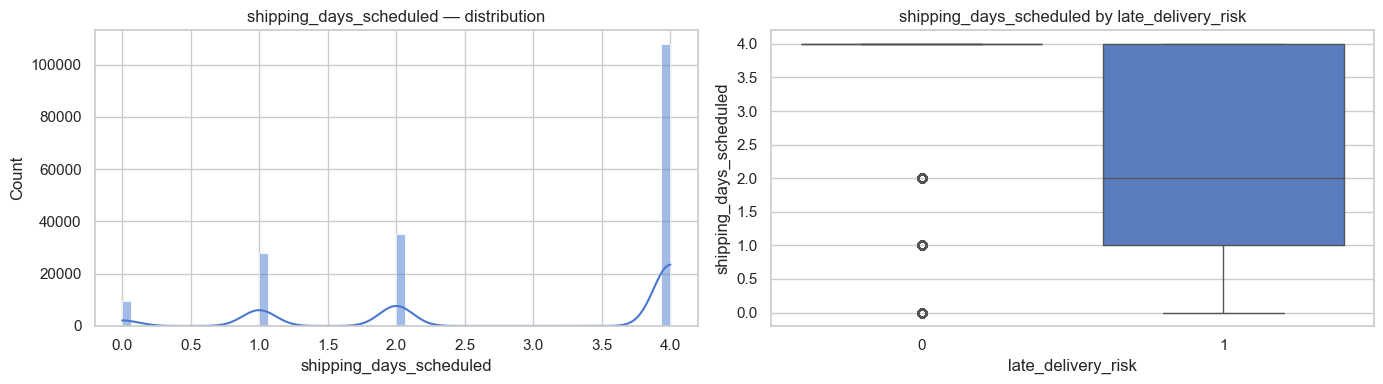

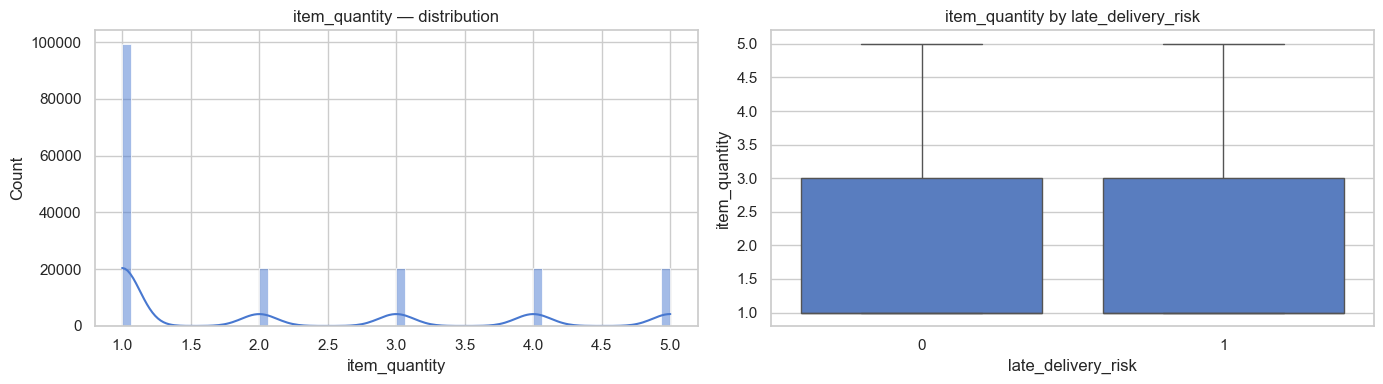

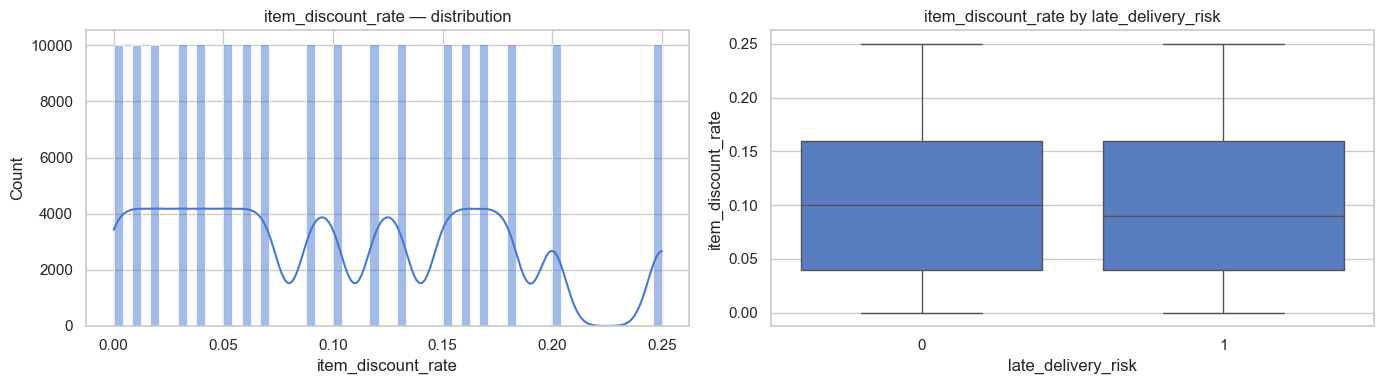

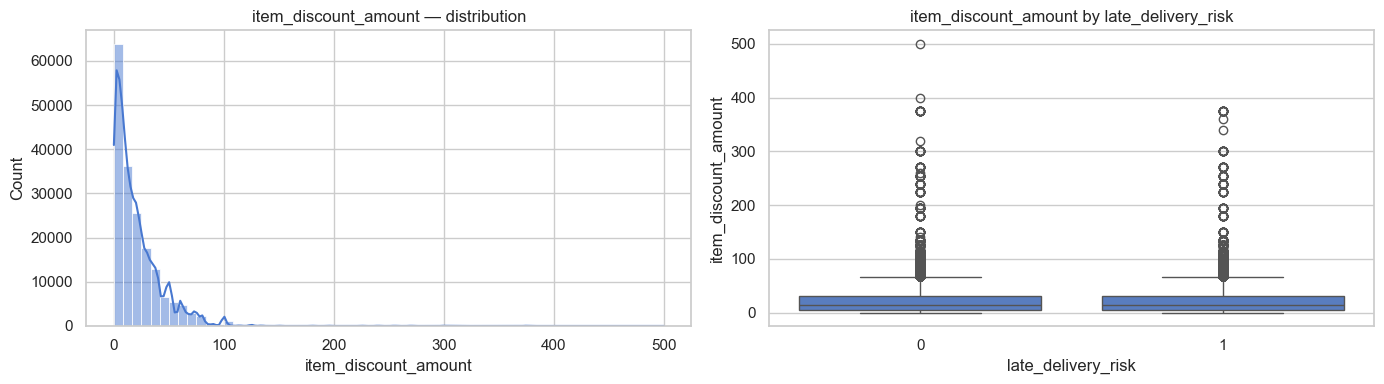

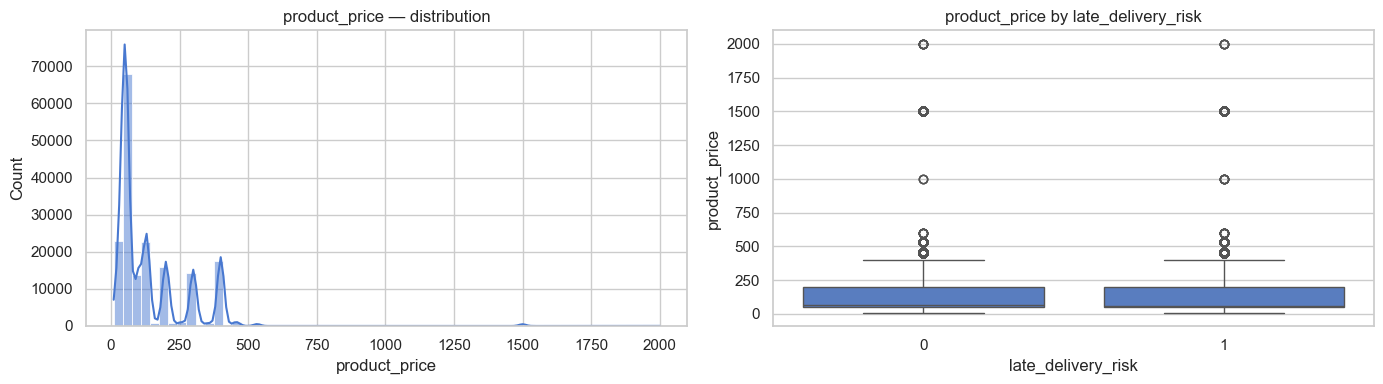

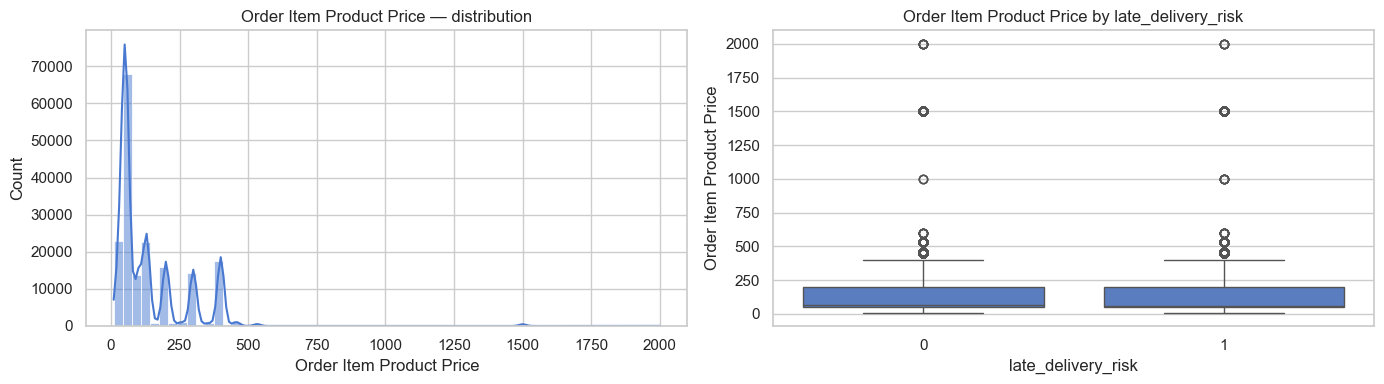

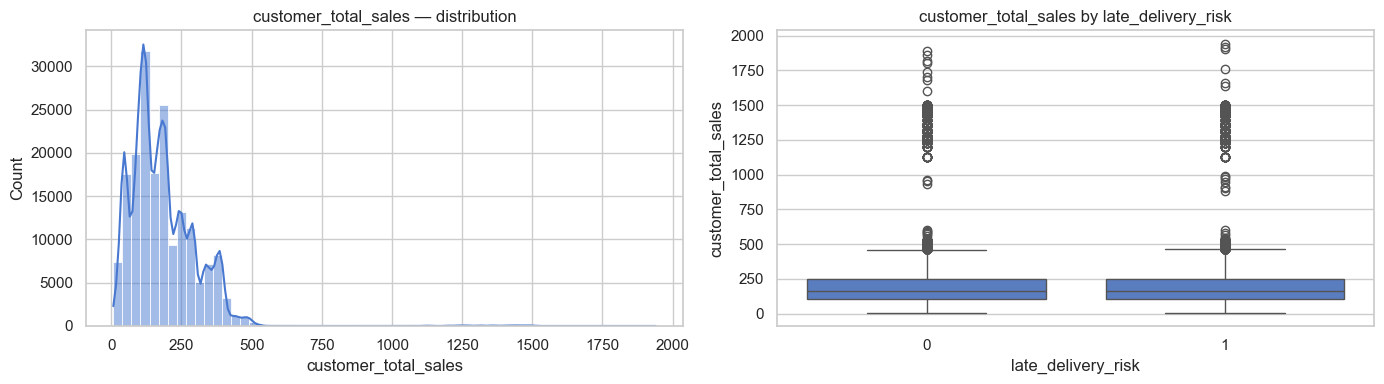

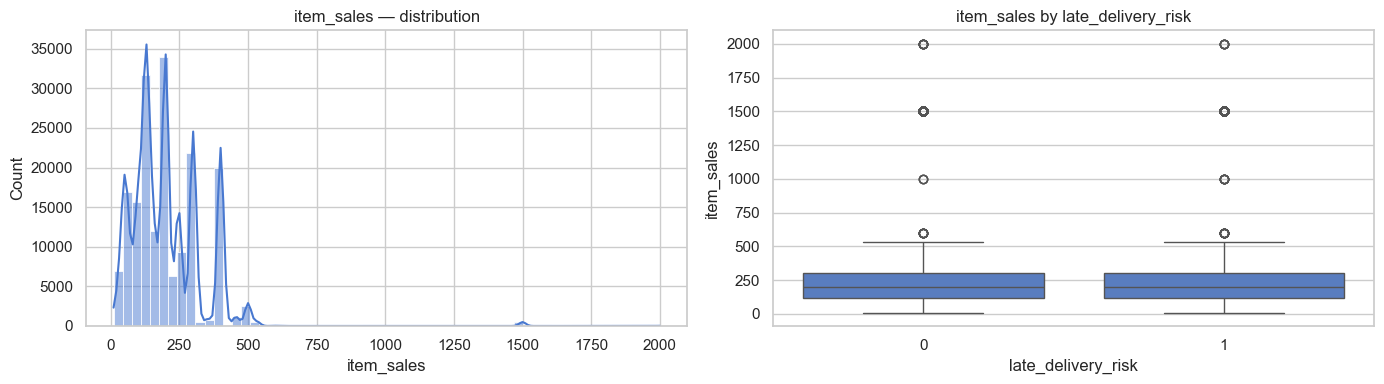

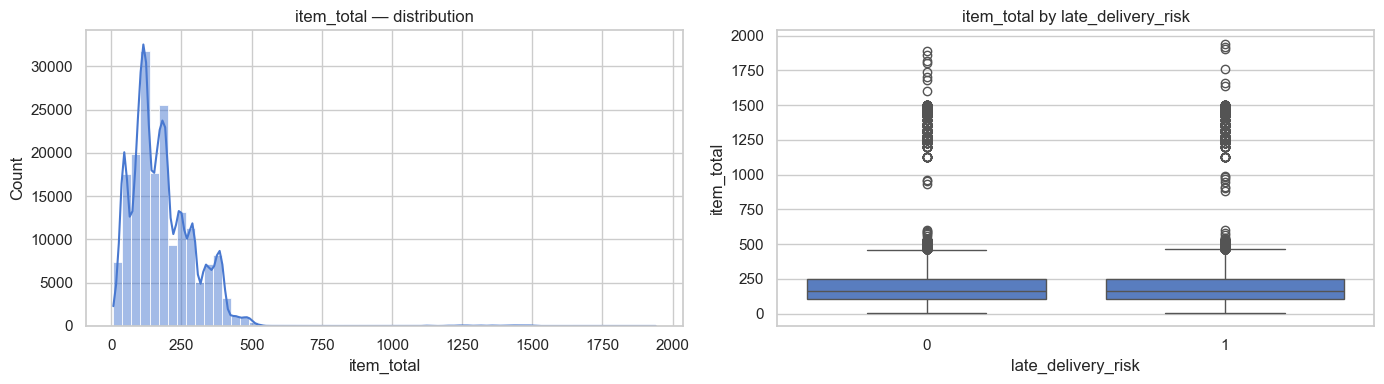

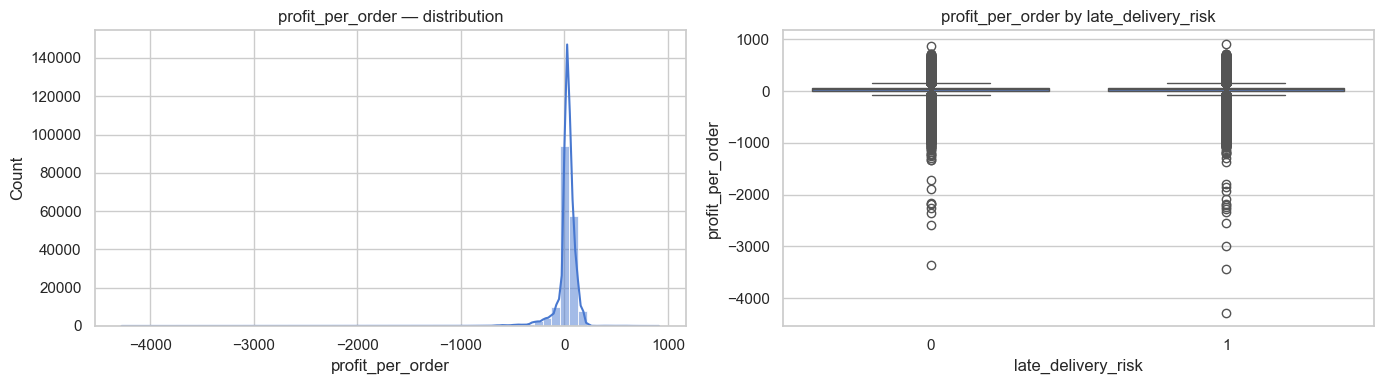

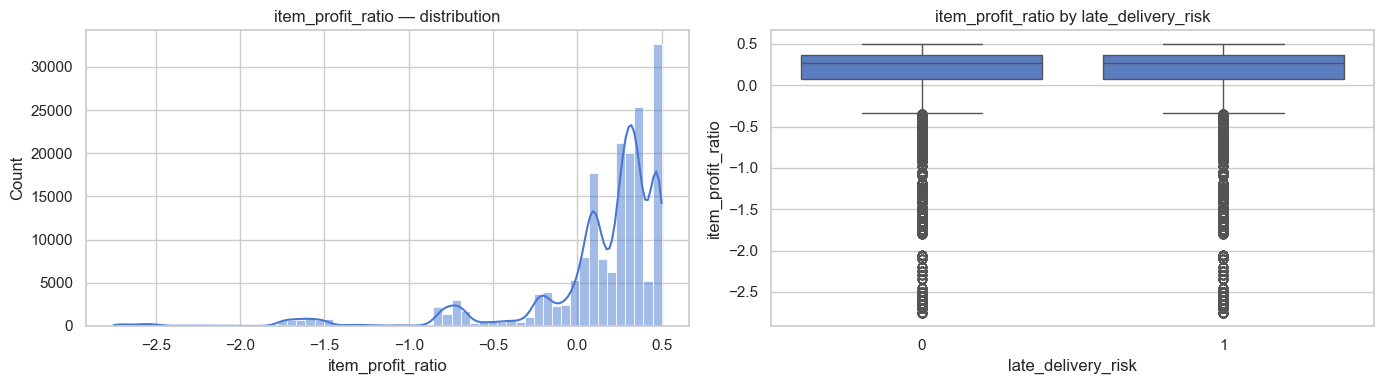

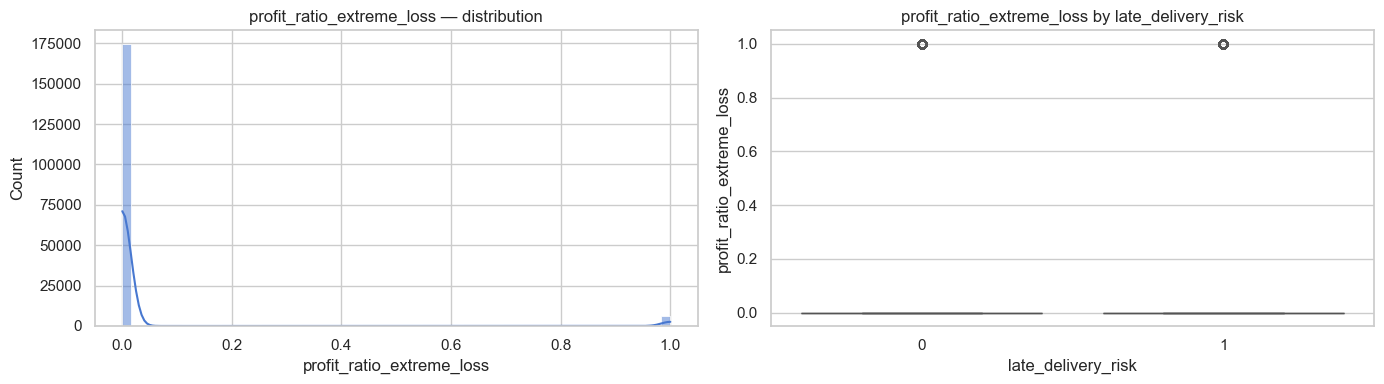

In [10]:
# ---- Numeric feature scan (univariate + by target) ----

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
# Exclude identifiers if present
id_like = [c for c in num_cols if c.lower().endswith(" id") or c.lower().endswith("id")]
num_cols = [c for c in num_cols if c not in id_like]

# Keep target out of feature scan
num_cols = [c for c in num_cols if c != TARGET]

print(f"Numeric columns (excluding id-like + target): {len(num_cols)}")

# Choose a high-signal subset for deep dives (finance + shipping schedule)
preferred = [
    "shipping_days_scheduled",
    "item_quantity",
    "item_discount_rate",
    "item_discount_amount",
    "product_price",
    "Order Item Product Price",
    "customer_total_sales",
    "item_sales",
    "item_total",
    "profit_per_order",
    "item_profit_ratio",
    "profit_ratio_extreme_loss",
]

focus_num = [c for c in preferred if c in df.columns]
if len(focus_num) == 0:
    focus_num = num_cols[:12]

for c in focus_num:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[c], bins=60, ax=axes[0], kde=True)
    axes[0].set_title(f"{c} — distribution")

    # robust visualization for skew
    sns.boxplot(data=df, x=TARGET, y=c, ax=axes[1])
    axes[1].set_title(f"{c} by {TARGET}")

    plt.tight_layout()
    plt.show()


### Step 6 – Categorical segments and late-rate by group

Now we look at **categories/segments** (like `shipping_mode`, `market`, `order_region`, etc.) and ask:

> In which segments is the late rate **high or low**, and do those segments also have **enough volume** to matter?

For each key categorical column we:
- Group by the category and compute **late rate** and **number of orders (n)**.
- Filter out tiny groups using a `min_n` threshold.
- Plot a **bar chart** ranked by late rate and annotate each bar with `n`.
- Show the underlying table for more precise numbers.

These plots are great for **business levers**: which markets, shipping modes, or customer segments are driving late delivery.

Categorical columns: 19
Key categorical columns found: ['shipping_mode', 'market', 'order_region', 'order_country', 'customer_segment', 'department_name', 'category_name', 'transaction_type', 'order_status']


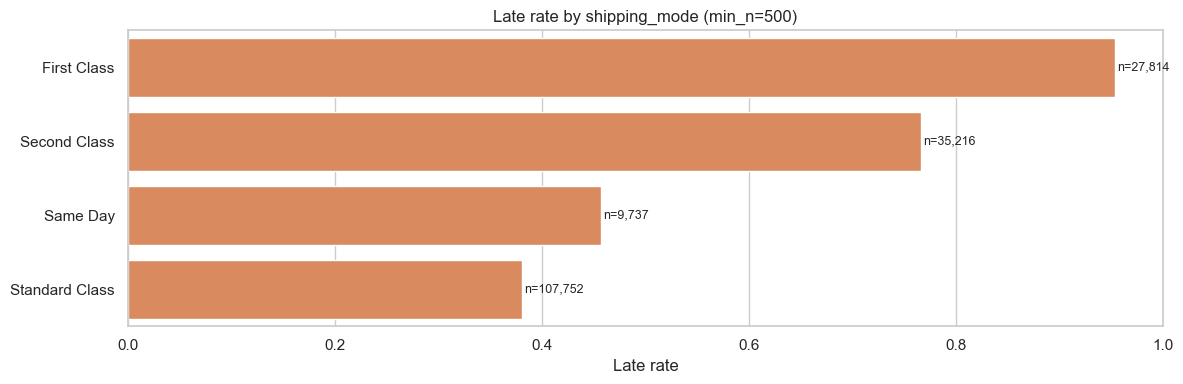

,late_rate,n
shipping_mode,,
First Class,0.953225,27814
Second Class,0.766328,35216
Same Day,0.457430,9737
Standard Class,0.380717,107752


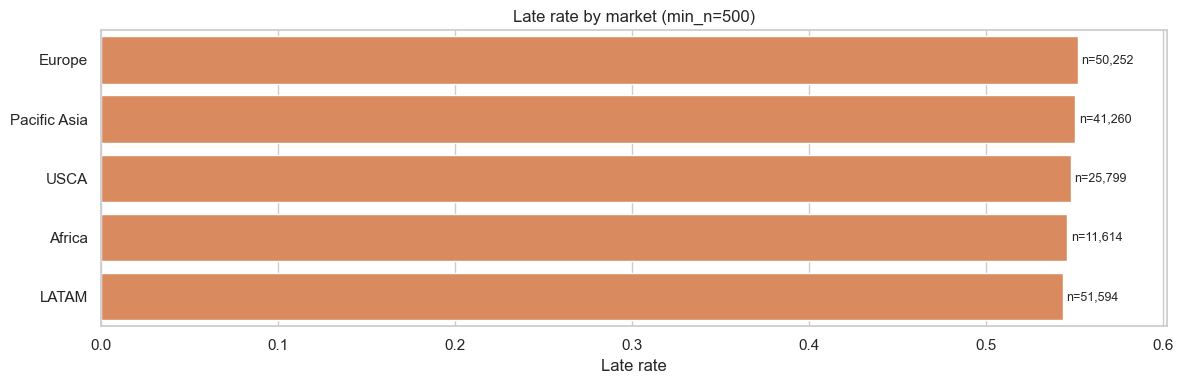

,late_rate,n
market,,
Europe,0.552078,50252
Pacific Asia,0.550460,41260
USCA,0.548006,25799
Africa,0.545893,11614
LATAM,0.543552,51594


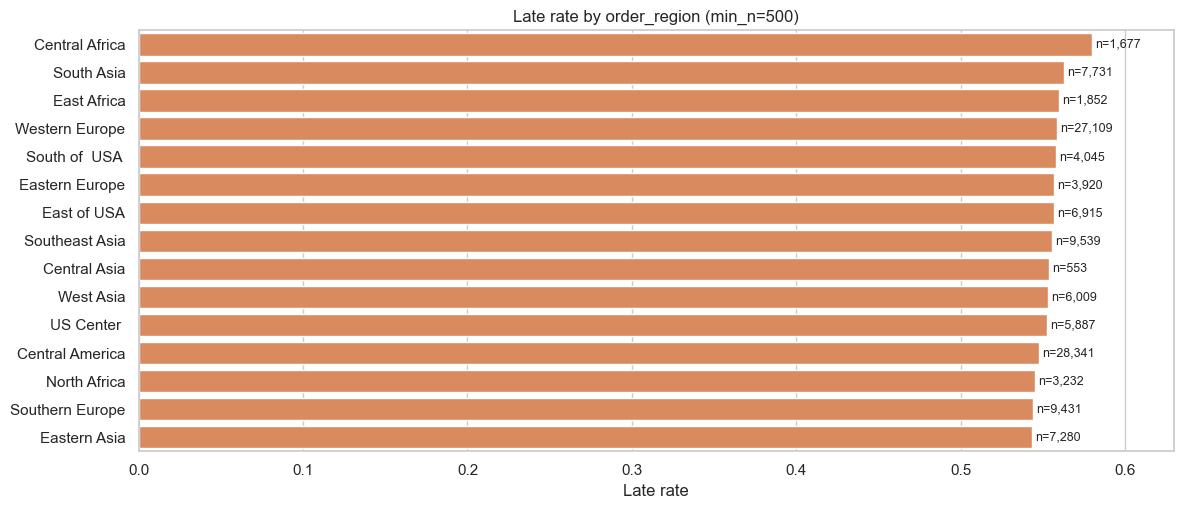

,late_rate,n
order_region,,
Central Africa,0.579606,1677
South Asia,0.562670,7731
East Africa,0.559395,1852
Western Europe,0.558486,27109
South of USA,0.557726,4045
Eastern Europe,0.556633,3920
East of USA,0.556616,6915
Southeast Asia,0.555299,9539
Central Asia,0.553345,553


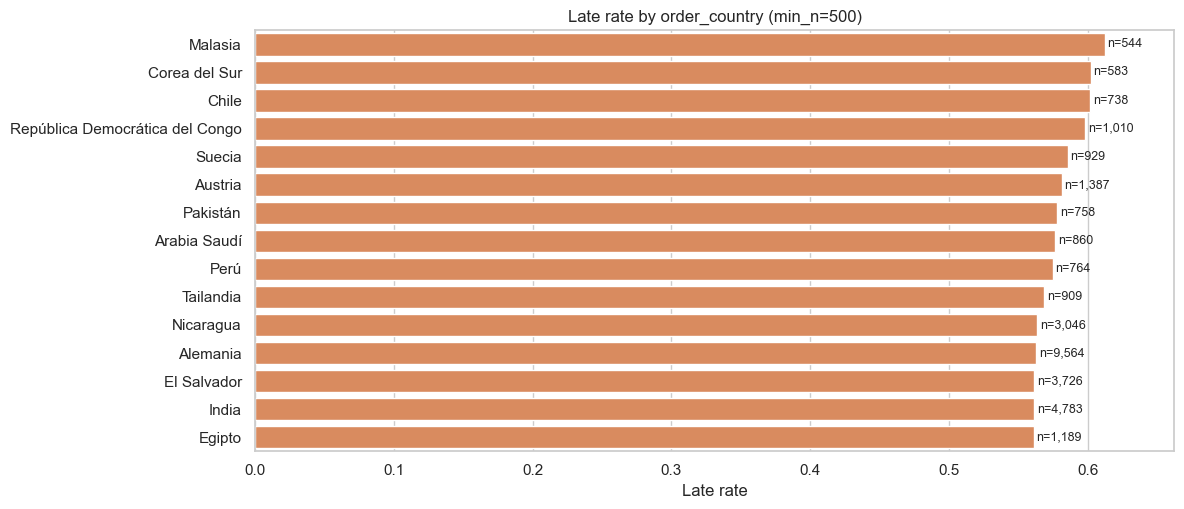

,late_rate,n
order_country,,
Malasia,0.612132,544
Corea del Sur,0.602058,583
Chile,0.601626,738
República Democrática del Congo,0.598020,1010
Suecia,0.585576,929
Austria,0.581110,1387
Pakistán,0.577836,758
Arabia Saudí,0.576744,860
Perú,0.574607,764


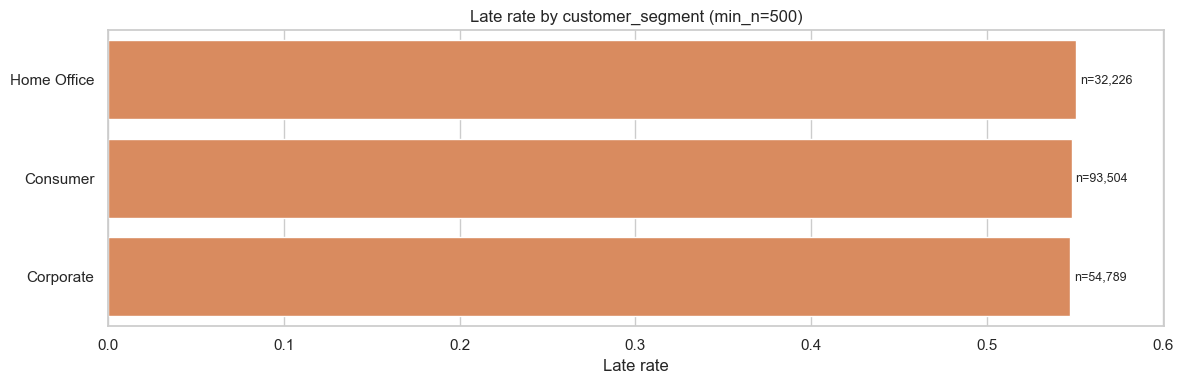

,late_rate,n
customer_segment,,
Home Office,0.550704,32226
Consumer,0.548084,93504
Corporate,0.547227,54789


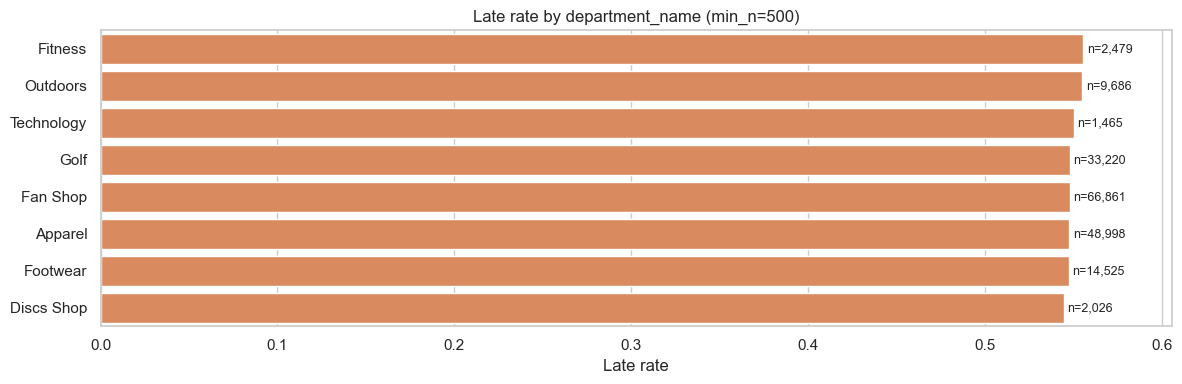

,late_rate,n
department_name,,
Fitness,0.555466,2479
Outdoors,0.554925,9686
Technology,0.550171,1465
Golf,0.547803,33220
Fan Shop,0.547748,66861
Apparel,0.547471,48998
Footwear,0.547263,14525
Discs Shop,0.544423,2026


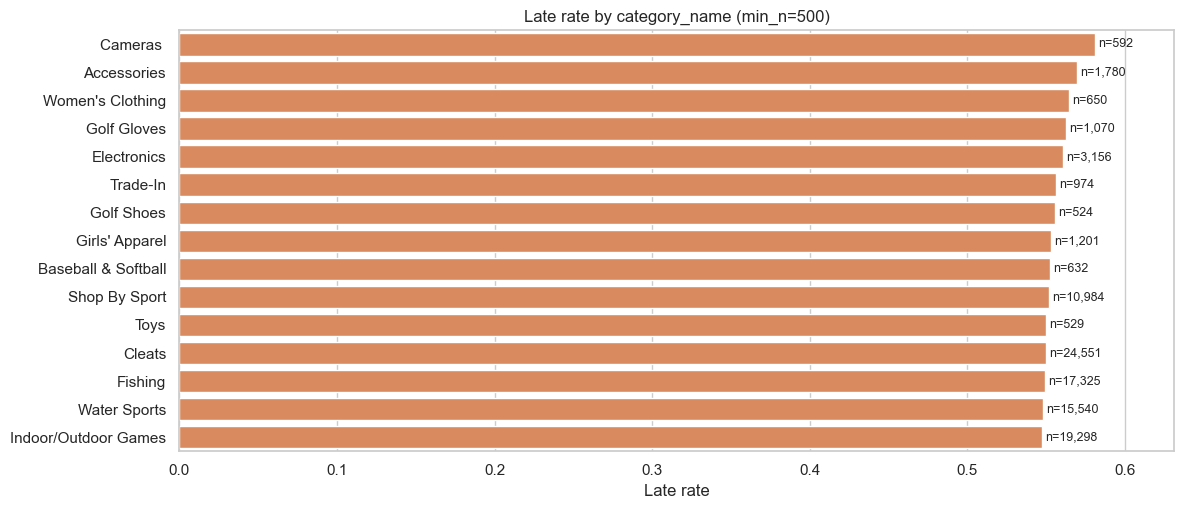

,late_rate,n
category_name,,
Cameras,0.581081,592
Accessories,0.569663,1780
Women's Clothing,0.564615,650
Golf Gloves,0.562617,1070
Electronics,0.560837,3156
Trade-In,0.556468,974
Golf Shoes,0.555344,524
Girls' Apparel,0.552873,1201
Baseball & Softball,0.552215,632


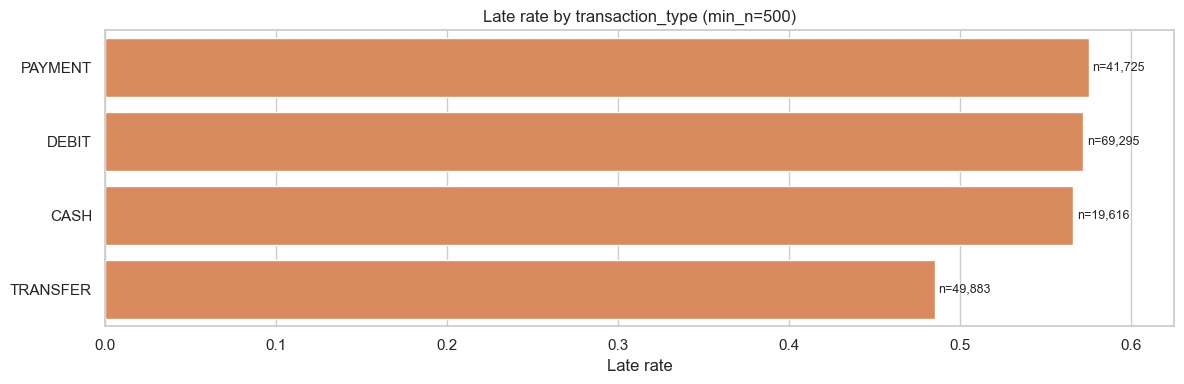

,late_rate,n
transaction_type,,
PAYMENT,0.575291,41725
DEBIT,0.572177,69295
CASH,0.566323,19616
TRANSFER,0.485436,49883


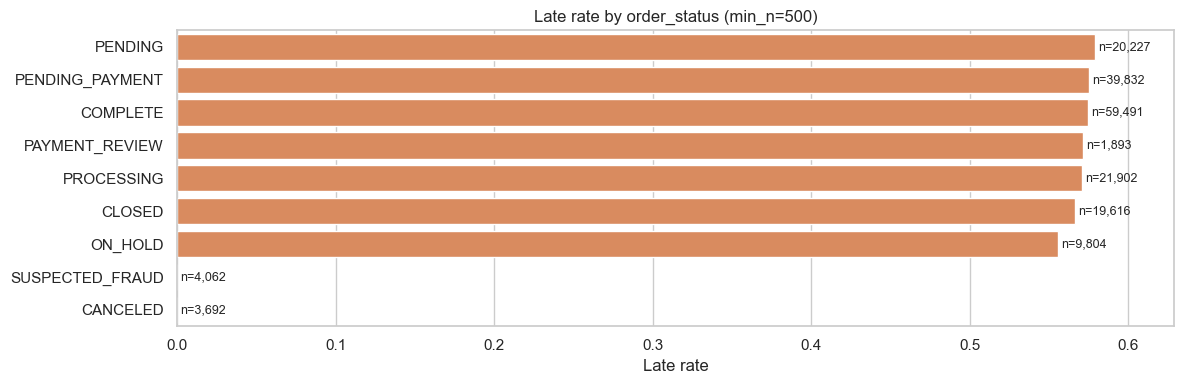

,late_rate,n
order_status,,
PENDING,0.579028,20227
PENDING_PAYMENT,0.575467,39832
COMPLETE,0.574860,59491
PAYMENT_REVIEW,0.571580,1893
PROCESSING,0.570861,21902
CLOSED,0.566323,19616
ON_HOLD,0.555896,9804
SUSPECTED_FRAUD,0.000000,4062
CANCELED,0.000000,3692


In [11]:
# ---- Categorical drivers (late-rate by segment with volume) ----

cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")

# High-signal business segments in this dataset
key_cats = [
    "shipping_mode",
    "market",
    "order_region",
    "order_country",
    "customer_segment",
    "department_name",
    "category_name",
    "transaction_type",
    "order_status",
]
key_cats = [c for c in key_cats if c in df.columns]
print("Key categorical columns found:", key_cats)


def late_rate_table(col: str, top_k: int = 15, min_n: int = 200) -> pd.DataFrame:
    g = df.groupby(col)[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "n"})
    g = g[g["n"] >= min_n].sort_values(["late_rate", "n"], ascending=[False, False])
    if len(g) > top_k:
        g = g.head(top_k)
    return g


def plot_late_rate(col: str, top_k: int = 15, min_n: int = 200):
    t = late_rate_table(col, top_k=top_k, min_n=min_n)
    if len(t) == 0:
        print(f"No groups meet min_n={min_n} for {col}.")
        return

    plot_df = t.reset_index()
    plt.figure(figsize=(12, max(4, 0.35 * len(plot_df))))
    ax = sns.barplot(data=plot_df, y=col, x="late_rate", hue=None, color=sns.color_palette()[1])

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["late_rate"] + 0.002, i, f"n={int(row['n']):,}", va="center", fontsize=9)

    plt.xlim(0, min(1.0, max(plot_df["late_rate"].max() + 0.05, 0.1)))
    plt.title(f"Late rate by {col} (min_n={min_n})")
    plt.xlabel("Late rate")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    display(t)


for c in key_cats:
    plot_late_rate(c, top_k=15, min_n=500)


### Step 7 – Time patterns in late delivery

We want to know **when** late deliveries tend to happen.

Using the cleaned `order_date` column we:
- Convert it to a proper datetime and drop invalid dates.
- Resample by **month** to compute monthly **late rate** and **order volume**.
- Plot a combined chart:
  - Line = late rate over time.
  - Bars = number of orders per month.
- Also derive **day-of-week** and plot late rate by weekday.

This reveals **seasonality or operational issues** (e.g., specific months or weekdays with systematically higher late risk).

Unparseable order_date: 0.00%


,late_rate,orders
order_date,,
2015-01-01,0.541150,5322
2015-02-01,0.548530,4729
2015-03-01,0.547557,5362
2015-04-01,0.538432,5126
2015-05-01,0.550868,5357


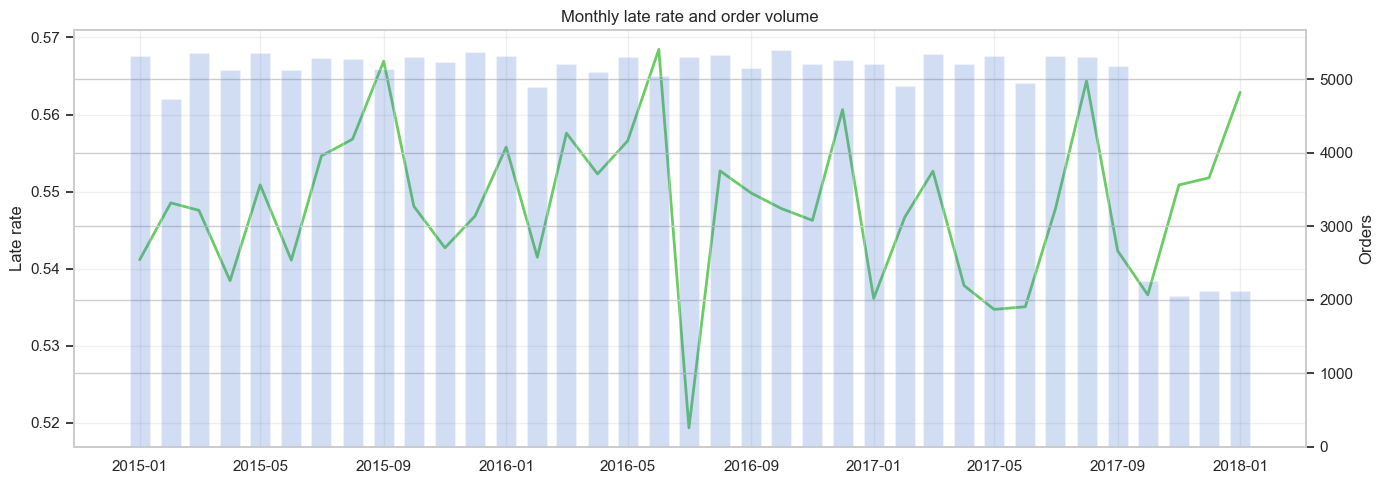

,late_rate,n
dow,,
Monday,0.550531,25786
Tuesday,0.543010,25622
Wednesday,0.547583,25587
Thursday,0.550054,25752
Friday,0.551707,25925
Saturday,0.543956,25901
Sunday,0.551145,25946


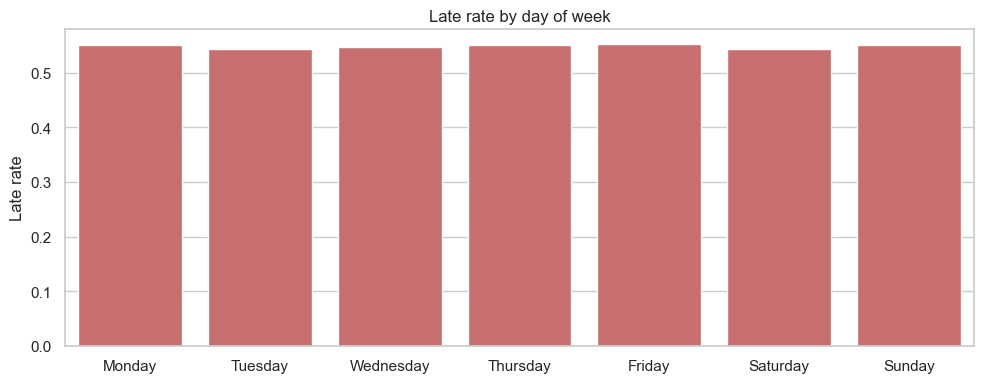

In [12]:
# ---- Time trends (order date) ----

date_col = "order_date"
if date_col in df.columns:
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    bad = d[date_col].isna().mean()
    print(f"Unparseable {date_col}: {bad:.2%}")

    d = d.dropna(subset=[date_col]).sort_values(date_col)
    d = d.set_index(date_col)

    monthly = d.resample("MS")[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "orders"})
    display(monthly.head())

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(monthly.index, monthly["late_rate"], color=sns.color_palette()[2], linewidth=2)
    ax1.set_ylabel("Late rate")
    ax1.set_title("Monthly late rate and order volume")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.bar(monthly.index, monthly["orders"], width=20, alpha=0.25, color=sns.color_palette()[0])
    ax2.set_ylabel("Orders")

    plt.tight_layout()
    plt.show()

    # Day-of-week effect
    dow = d.copy()
    dow["dow"] = dow.index.day_name()
    dow_tbl = dow.groupby("dow")[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "n"})
    # Order by typical week
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_tbl = dow_tbl.reindex(order)
    display(dow_tbl)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=dow_tbl.reset_index(), x="dow", y="late_rate", color=sns.color_palette()[3])
    plt.title("Late rate by day of week")
    plt.xlabel("")
    plt.ylabel("Late rate")
    plt.tight_layout()
    plt.show()
else:
    print(f"Column not found: {date_col}")


### Step 8 – Correlations with the target (numeric view)

Here we examine how strongly each numeric feature is **monotonically associated** with `late_delivery_risk`.

- We take all numeric columns and compute a **Spearman correlation matrix**.
- We sort features by absolute correlation with the target and list the **top 20**.
- For the strongest ones, we plot a **heatmap** of the correlation sub-matrix.

This gives a quick sense of which numeric signals are most relevant for modeling (keeping in mind that some may still be leakage or highly redundant with others).

shipping_days_scheduled     -0.388240
shipping_days_actual         0.367384
profit_ratio_extreme_loss    0.003470
profit_per_order            -0.002947
item_sales                  -0.002832
customer_zipcode             0.002764
customer_total_sales        -0.002654
item_total                  -0.002654
order_month                  0.002601
product_price               -0.002541
Order Item Product Price    -0.002541
order_year                  -0.002363
store_longitude             -0.002341
item_discount_amount        -0.002121
order_id                    -0.001376
order_item_id               -0.001376
order_weekday                0.001119
order_quarter                0.001099
customer_id                  0.001030
item_profit_ratio           -0.000987
Name: late_delivery_risk, dtype: float64

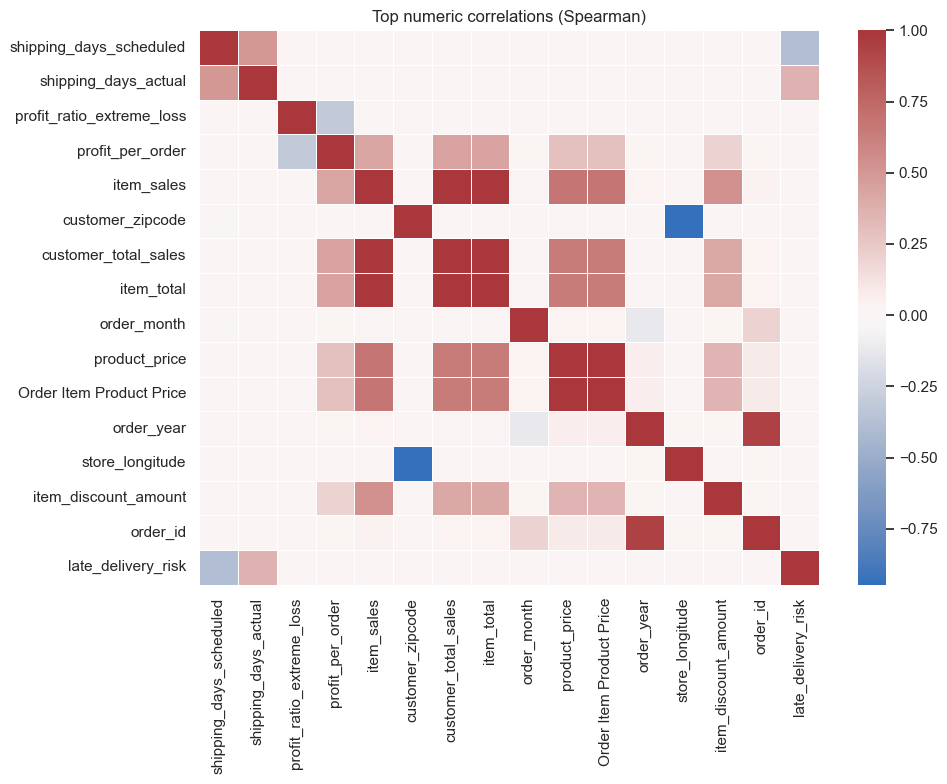

In [13]:
# ---- Correlations (numeric) + relationship to target ----

num = df.select_dtypes(include=["number"]).copy()
if TARGET in num.columns:
    # Spearman tends to be more robust with heavy skew
    corr = num.corr(method="spearman")

    # Show strongest relationships with target (excluding obvious leakage if present)
    s = corr[TARGET].drop(labels=[TARGET], errors="ignore").sort_values(key=lambda x: x.abs(), ascending=False)
    display(s.head(20))

    # Heatmap on a manageable subset
    top_cols = s.head(15).index.tolist() + [TARGET]
    top_corr = corr.loc[top_cols, top_cols]

    plt.figure(figsize=(10, 8))
    sns.heatmap(top_corr, annot=False, cmap="vlag", center=0, linewidths=0.5)
    plt.title("Top numeric correlations (Spearman)")
    plt.tight_layout()
    plt.show()
else:
    print("Target not numeric; skipping correlation analysis.")


### Step 9 – Geographic sanity check

We use `store_latitude` and `store_longitude` to see if there are **geographic clusters** of high late risk.

- We sample up to 10,000 orders for readability.
- We plot points in latitude/longitude space, colored by `late_delivery_risk`.

This isn’t a precise spatial model, but it can show whether particular **regions or countries** stand out visually as late-delivery hotspots.

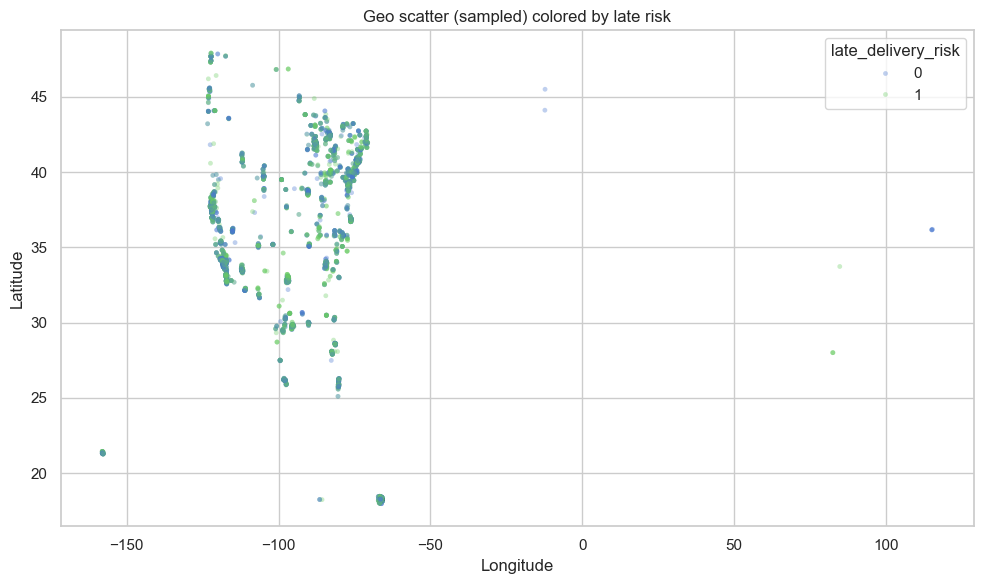

In [14]:
# ---- Geo sanity (sampled) ----

lat_col, lon_col = "store_latitude", "store_longitude"
if lat_col in df.columns and lon_col in df.columns:
    g = df[[lat_col, lon_col, TARGET]].dropna().copy()
    if len(g) > 10_000:
        g = g.sample(10_000, random_state=42)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=g,
        x=lon_col,
        y=lat_col,
        hue=TARGET,
        alpha=0.35,
        s=12,
        palette={0: sns.color_palette()[0], 1: sns.color_palette()[2]},
        linewidth=0,
    )
    plt.title("Geo scatter (sampled) colored by late risk")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title=TARGET)
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude not found; skipping geo plot.")


### Step 10 – Automated insight summary

Finally, we summarize the **most important segments** where late rate is meaningfully different from the global baseline.

- We compute the overall **baseline late rate**.
- For key segment columns (e.g., `shipping_mode`, `market`, `order_region`), we calculate per-group:
  - number of orders `n`
  - late rate
  - **lift in percentage points** vs baseline.
- We rank segments by a combined **score** that favors both **large lift** and **large volume**.
- We display the top rows in a table and print **ready-to-use bullet sentences** like:
  
  > `shipping_mode = Same Day: late rate 18.2% (5.4 pp higher than baseline; n=12,345)`

These bullets are meant to drop directly into your report or slides as data-backed findings.

## What to extract from this EDA (deliverables)

- **Operational levers**: which `Shipping Mode`, `Market`, `Order Region/Country`, and product segments have materially higher late rates **at meaningful volume**.
- **Seasonality**: whether late delivery spikes by month / day-of-week.
- **Financial trade-offs**: how discounting, quantities, and product price relate to late risk (and whether those relationships are confounded by region/market).
- **Leakage risks**: columns that encode outcomes (e.g., actual shipping days, delivery status) must not be used as predictors.

If you want, we can add a final “Insight Summary” section that programmatically prints the top 10 highest-confidence findings (with counts + late-rate deltas).


In [15]:
# ---- Insight summary (high-confidence, report-ready) ----

baseline = float(df[TARGET].mean())
print(f"Overall late rate: {baseline:.3f} ({baseline*100:.1f}%)")

summary_cols = [c for c in ["shipping_mode", "market", "order_region", "order_country", "customer_segment", "department_name", "category_name"] if c in df.columns]

rows = []
for col in summary_cols:
    tbl = df.groupby(col)[TARGET].agg(["mean", "size"]).rename(columns={"mean": "late_rate", "size": "n"})
    # keep meaningful volume; adjust threshold if needed
    tbl = tbl[tbl["n"] >= 1000].copy()
    if len(tbl) == 0:
        continue
    tbl["lift_pp"] = (tbl["late_rate"] - baseline) * 100
    tbl["col"] = col
    tbl["level"] = tbl.index.astype(str)
    rows.append(tbl.reset_index(drop=True)[["col", "level", "n", "late_rate", "lift_pp"]])

if len(rows) == 0:
    print("No summary segments met the minimum volume threshold.")
else:
    summary = pd.concat(rows, ignore_index=True)
    # “highest-confidence” = big volume + big lift
    summary["score"] = summary["lift_pp"].abs() * np.log10(summary["n"].clip(lower=2))
    summary = summary.sort_values(["score", "lift_pp"], ascending=[False, False])

    display(summary.head(25).drop(columns=["score"]))

    print("\nReport bullets (copy/paste):")
    for _, r in summary.head(10).iterrows():
        direction = "higher" if r["lift_pp"] > 0 else "lower"
        print(
            f"- {r['col']} = {r['level']}: late rate {r['late_rate']*100:.1f}% "
            f"({abs(r['lift_pp']):.1f} pp {direction} than baseline; n={int(r['n']):,})"
        )


Overall late rate: 0.548 (54.8%)


,col,level,n,late_rate,lift_pp
0,shipping_mode,First Class,27814,0.953225,40.493368
2,shipping_mode,Second Class,35216,0.766328,21.803649
3,shipping_mode,Standard Class,107752,0.380717,-16.757448
1,shipping_mode,Same Day,9737,0.457430,-9.086090
58,order_country,República Democrática del Congo,1010,0.598020,4.972849
37,order_country,Cuba,3534,0.508772,-3.951939
55,order_country,Panamá,1941,0.506955,-4.133614
36,order_country,Colombia,1771,0.512705,-3.558663
33,order_country,Austria,1387,0.581110,3.281899
31,order_country,Argentina,1931,0.517349,-3.094279



Report bullets (copy/paste):
- shipping_mode = First Class: late rate 95.3% (40.5 pp higher than baseline; n=27,814)
- shipping_mode = Second Class: late rate 76.6% (21.8 pp higher than baseline; n=35,216)
- shipping_mode = Standard Class: late rate 38.1% (16.8 pp lower than baseline; n=107,752)
- shipping_mode = Same Day: late rate 45.7% (9.1 pp lower than baseline; n=9,737)
- order_country = República Democrática del Congo: late rate 59.8% (5.0 pp higher than baseline; n=1,010)
- order_country = Cuba: late rate 50.9% (4.0 pp lower than baseline; n=3,534)
- order_country = Panamá: late rate 50.7% (4.1 pp lower than baseline; n=1,941)
- order_country = Colombia: late rate 51.3% (3.6 pp lower than baseline; n=1,771)
- order_country = Austria: late rate 58.1% (3.3 pp higher than baseline; n=1,387)
- order_country = Argentina: late rate 51.7% (3.1 pp lower than baseline; n=1,931)
